In [12]:
%pip install kagglehub python-dotenv

import os
from dotenv import load_dotenv
import kagglehub

load_dotenv()

if not os.getenv("KAGGLE_API_TOKEN"):
    raise RuntimeError("KAGGLE_API_TOKEN is not set. Add it to .env or set it in your environment.")

# Download latest version
path = kagglehub.dataset_download("davidcariboo/player-scores")

print("Path to dataset files:", path)

Note: you may need to restart the kernel to use updated packages.
Path to dataset files: /Users/koenamukherjee/.cache/kagglehub/datasets/davidcariboo/player-scores/versions/677


In [5]:
pip install pandas scikit-learn matplotlib seaborn jupyter

  Using cached pandas-3.0.5-cp313-cp313-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached scikit_learn-1.9.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached matplotlib-3.11.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached numpy-2.5.2-cp313-cp313-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached scipy-1.18.1-cp313-cp313-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.25.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-macosx_10_13_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1

In [6]:
import pandas as pd

print(os.listdir(path))

['game_lineups.csv', 'competitions.csv', 'appearances.csv', 'countries.csv', 'player_valuations.csv', 'game_events.csv', 'transfers.csv', 'players.csv', 'games.csv', 'club_games.csv', 'national_teams.csv', 'clubs.csv']


In [8]:
df = pd.read_csv(os.path.join(path, "players.csv"))

In [10]:
columns_to_keep = ['name', 'position', 'market_value_in_eur', 'current_club_name']

df_filtered = df[columns_to_keep]

df_clean = df_filtered.dropna(subset=['market_value_in_eur'])

df_sorted = df_clean.sort_values(by='market_value_in_eur', ascending=False)

top_10 = df_sorted.head(10)

In [11]:
print("--- TOP 10 MOST VALUABLE PLAYERS ---")
print(top_10.to_string(index=False))

--- TOP 10 MOST VALUABLE PLAYERS ---
                 name position  market_value_in_eur   current_club_name
         Lamine Yamal   Attack          200000000.0        FC Barcelona
       Erling Haaland   Attack          200000000.0     Manchester City
        Kylian Mbappé   Attack          180000000.0         Real Madrid
                Pedri Midfield          150000000.0        FC Barcelona
        Michael Olise   Attack          150000000.0       Bayern Munich
              Vitinha Midfield          140000000.0 Paris Saint-Germain
Khvicha Kvaratskhelia   Attack          140000000.0 Paris Saint-Germain
      Vinicius Junior   Attack          140000000.0         Real Madrid
           João Neves Midfield          140000000.0 Paris Saint-Germain
      Jude Bellingham Midfield          130000000.0         Real Madrid


In [19]:
## age vs. market value (hyp: younger players are more valuable)

columns_to_analyze = ['name', 'date_of_birth', 'market_value_in_eur', 'position']
df_clean = df[columns_to_analyze].dropna()

# 3. Convert birth dates to datetime objects
df_clean['date_of_birth'] = pd.to_datetime(df_clean['date_of_birth'])

# 4. Calculate integer age using 2026 as the baseline year
df_clean['age'] = (2026 - df_clean['date_of_birth'].dt.year).astype(int)

# 5. Extract, isolate, and format the top 10 most valuable players
top_10 = df_clean.sort_values(by='market_value_in_eur', ascending=False).head(10).copy()
top_10['market_value_m'] = top_10['market_value_in_eur'] / 1_000_000
top_10 = top_10.reset_index(drop=True)

# 6. Print the finalized data table to the terminal
print("--- TOP 10 PLAYERS BY AGE & VALUE ---")
print(top_10[['name', 'age', 'market_value_m', 'position']].to_string(index=False))

--- TOP 10 PLAYERS BY AGE & VALUE ---
                 name  age  market_value_m position
       Erling Haaland   26           200.0   Attack
         Lamine Yamal   19           200.0   Attack
        Kylian Mbappé   28           180.0   Attack
        Michael Olise   25           150.0   Attack
                Pedri   24           150.0 Midfield
              Vitinha   26           140.0 Midfield
           João Neves   22           140.0 Midfield
Khvicha Kvaratskhelia   25           140.0   Attack
      Vinicius Junior   26           140.0   Attack
      Jude Bellingham   23           130.0 Midfield


findfont: Failed to find font weight semibold, now using 700.


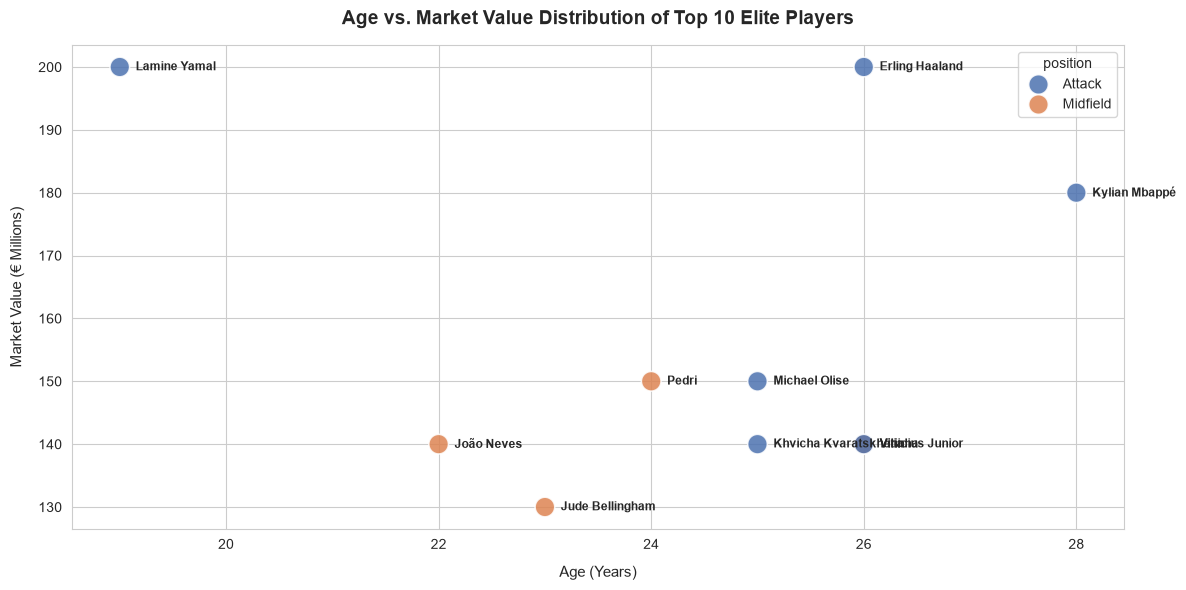

In [20]:
## plotting 

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))

## scatter plot
ax = sns.scatterplot(
  data=top_10,
  x='age',
  y='market_value_m',
  hue='position',
  s=200, # marker size
  palette='deep',
  alpha=0.85 # transparency
)

## labels
for idx, row in top_10.iterrows():
  ax.text(
    x=row['age'] + 0.15,         # Shift slightly right of the dot
    y=row['market_value_m'],     # Keep vertical level the same
    s=row['name'],               # The text to display
    horizontalalignment='left',
    size='small',
    verticalalignment='center',
    weight='semibold'
  )

## title
plt.title('Age vs. Market Value Distribution of Top 10 Elite Players', fontsize=14, pad=15, weight='bold')
plt.xlabel('Age (Years)', fontsize=11, labelpad=10)
plt.ylabel('Market Value (€ Millions)', fontsize=11, labelpad=10)

# Clean up layout and display the window
plt.tight_layout()
plt.show()

In [14]:
## position data (hyp: forwards cost more since they are crucial for scoring goals)

# Group the entire dataset by position and find the average market value
position_value = df.groupby('position')['market_value_in_eur'].mean().reset_index()

# Sort by highest average value to see which position is the most expensive
print(position_value.sort_values(by='market_value_in_eur', ascending=False))

     position  market_value_in_eur
0      Attack         1.807509e+06
3    Midfield         1.668365e+06
1    Defender         1.406029e+06
2  Goalkeeper         7.124642e+05
4     Missing         1.508527e+05
